# Exploración integral y auditoría de datos procesados (`data/processed/`)

Este cuaderno realiza una inspección unificada a simple vista de todos los conjuntos de datos generados y almacenados en el directorio `data/processed/`.

## Objetivos del cuaderno
1. **Resumen ejecutivo unificado**: Auditoría completa de los 13 archivos procesados en una sola tabla comparativa.
2. **Volumen y peso de datos**: Visualización comparativa de los pesos en MB y conteo de registros por dataset.
3. **Ficha técnica por archivo**: Muestra de estructura (`head`), tipos de datos (`dtypes`) y análisis de valores vacíos/nulos para cada tabla.
4. **Visualización de capas geoespaciales**: Representación del mapa de los 311 municipios de la provincia de Barcelona.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Configuración estacional y visual de matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Funciones auxiliares

Se definen las funciones para escanear automáticamente el directorio `data/processed/`, generar la tabla ejecutiva, renderizar gráficos de volumen por dataset y auditar cada archivo de manera estructurada con sus correspondientes docstrings.

In [2]:
def escanear_directorio_procesado(directorio_datos: str) -> pd.DataFrame:
    """Escanea el directorio procesado y calcula pesos en MB, dimensiones y nulos globales.

    Args:
        directorio_datos (str): Ruta a la carpeta data/processed.

    Returns:
        pd.DataFrame: Tabla resumida con el catálogo completo de archivos.
    """
    archivos = sorted(os.listdir(directorio_datos))
    resumen = []
    
    for f in archivos:
        path = os.path.join(directorio_datos, f)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        ext = os.path.splitext(f)[1].lower()
        
        filas, cols, pct_nulos = None, None, None
        try:
            if ext == '.csv':
                df = pd.read_csv(path, low_memory=False)
                filas, cols = df.shape
                pct_nulos = round(df.isna().mean().mean() * 100, 2)
            elif ext in ['.geojson', '.json']:
                try:
                    gdf = gpd.read_file(path)
                    filas, cols = gdf.shape
                    pct_nulos = round(gdf.isna().mean().mean() * 100, 2)
                except Exception:
                    df = pd.read_json(path)
                    filas, cols = df.shape
                    pct_nulos = round(df.isna().mean().mean() * 100, 2)
        except Exception as e:
            filas, cols, pct_nulos = 'Error', str(e), 0.0
            
        resumen.append({
            'archivo': f,
            'extension': ext,
            'tamaño_mb': round(size_mb, 2),
            'filas': filas,
            'columnas': cols,
            'pct_nulos_global': pct_nulos
        })
        
    return pd.DataFrame(resumen)

def generar_grafico_resumen_archivos(df_resumen: pd.DataFrame) -> None:
    """Genera un gráfico comparativo de barras horizontales con el tamaño en MB y el número de filas por archivo.

    Args:
        df_resumen (pd.DataFrame): DataFrame obtenido de escanear_directorio_procesado.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico 1: Tamaños en MB
    df_sorted_size = df_resumen.sort_values('tamaño_mb', ascending=True)
    barras1 = ax1.barh(df_sorted_size['archivo'], df_sorted_size['tamaño_mb'], color='#2b5c8f', alpha=0.85)
    for barra in barras1:
        ancho = barra.get_width()
        ax1.annotate(f'{ancho:.2f} MB', xy=(ancho, barra.get_y() + barra.get_height()/2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=8, fontweight='bold', color='#333333')
        
    ax1.set_title('Tamaño de los archivos procesados (en MB)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Tamaño (MB)', fontsize=10)
    
    # Gráfico 2: Número de filas (excluyendo valores no numéricos)
    df_rows = df_resumen[df_resumen['filas'].apply(lambda x: isinstance(x, (int, float)))].sort_values('filas', ascending=True)
    barras2 = ax2.barh(df_rows['archivo'], df_rows['filas'], color='#d95f02', alpha=0.85)
    for barra in barras2:
        ancho = barra.get_width()
        ax2.annotate(f'{ancho:,.0f}', xy=(ancho, barra.get_y() + barra.get_height()/2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=8, fontweight='bold', color='#333333')
        
    ax2.set_title('Número de registros/filas por archivo', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Filas', fontsize=10)
    
    plt.tight_layout()
    plt.show()

def mostrar_auditoria_archivo(ruta_archivo: str, max_filas_muestra: int = 3) -> None:
    """Carga un archivo individual de la carpeta procesada y muestra sus metadatos, nulos y vista previa.

    Args:
        ruta_archivo (str): Ruta completa al archivo.
        max_filas_muestra (int, optional): Número de filas a mostrar en la vista previa. Por defecto 3.
    """
    nombre_fichero = os.path.basename(ruta_archivo)
    ext = os.path.splitext(nombre_fichero)[1].lower()
    
    print("==================================================================================")
    print(f"FICHA TÉCNICA: {nombre_fichero}")
    print("==================================================================================")
    
    try:
        if ext == '.csv':
            df = pd.read_csv(ruta_archivo, low_memory=False)
        elif ext in ['.geojson', '.json']:
            try:
                df = gpd.read_file(ruta_archivo)
            except Exception:
                df = pd.read_json(ruta_archivo)
        else:
            print(f"Formato de archivo {ext} no soportado para lectura directa.")
            return
            
        print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
        print(f"Memoria ocupada: {df.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")
        
        # Tabla de columnas, dtypes y nulos
        nulos_col = df.isna().sum()
        pct_nulos_col = (df.isna().mean() * 100).round(2)
        tabla_col = pd.DataFrame({
            'tipo_dato': df.dtypes,
            'valores_nulos': nulos_col,
            'pct_nulos': pct_nulos_col
        })
        print("--- COLUMNAS Y COBERTURA DE DATOS ---")
        display(tabla_col)
        
        print("--- VISTA PREVIA (PRIMERAS FILAS) ---")
        display(df.head(max_filas_muestra))
        
    except Exception as e:
        print(f"Error al leer el archivo {nombre_fichero}: {e}")

def visualizar_mapa_municipios(ruta_geojson: str) -> None:
    """Renderiza la cartografía de los municipios de la provincia de Barcelona.

    Args:
        ruta_geojson (str): Ruta al archivo GeoJSON de municipios.
    """
    try:
        gdf_mun = gpd.read_file(ruta_geojson)
        fig, ax = plt.subplots(figsize=(12, 8))
        gdf_mun.plot(ax=ax, color='#e0ecf4', edgecolor='#888888', linewidth=0.5)
        ax.set_title(f'Mapa de los {len(gdf_mun)} municipios de la provincia de Barcelona (Geometría oficial)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Longitud / X', fontsize=10)
        ax.set_ylabel('Latitud / Y', fontsize=10)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error al visualizar mapa geoespacial: {e}")

## 1. Escaneo global y resumen ejecutivo de `data/processed/`

Analizamos la totalidad de archivos guardados en la carpeta de datos procesados del proyecto (`data/processed/`).

--- CATÁLOGO EJECUTIVO DE DATOS PROCESADOS (DATA/PROCESSED) ---


,archivo,extension,tamaño_mb,filas,columnas,pct_nulos_global
0,airbnb_situacion_licencia.csv,.csv,5.40,15406,29,11.49
1,geocodificacion_icgc.csv,.csv,1.43,14474,9,13.40
2,geocodificacion_verificada.csv,.csv,1.52,12982,11,9.25
3,hoteles_con_precio.csv,.csv,0.10,754,17,13.07
4,hoteles_cruce_base.csv,.csv,0.10,754,17,11.80
5,hoteles_geocodificados.csv,.csv,0.03,309,7,14.75
6,hoteles_y_apartaments_unificados.csv,.csv,0.29,1563,24,19.98
7,municipios_provincia_barcelona.geojson,.geojson,13.08,311,21,0.00
8,otb_perfil_turista_2025-11.csv,.csv,0.00,3,7,0.00
9,restauracion_con_municipio.csv,.csv,1.91,16801,16,39.99


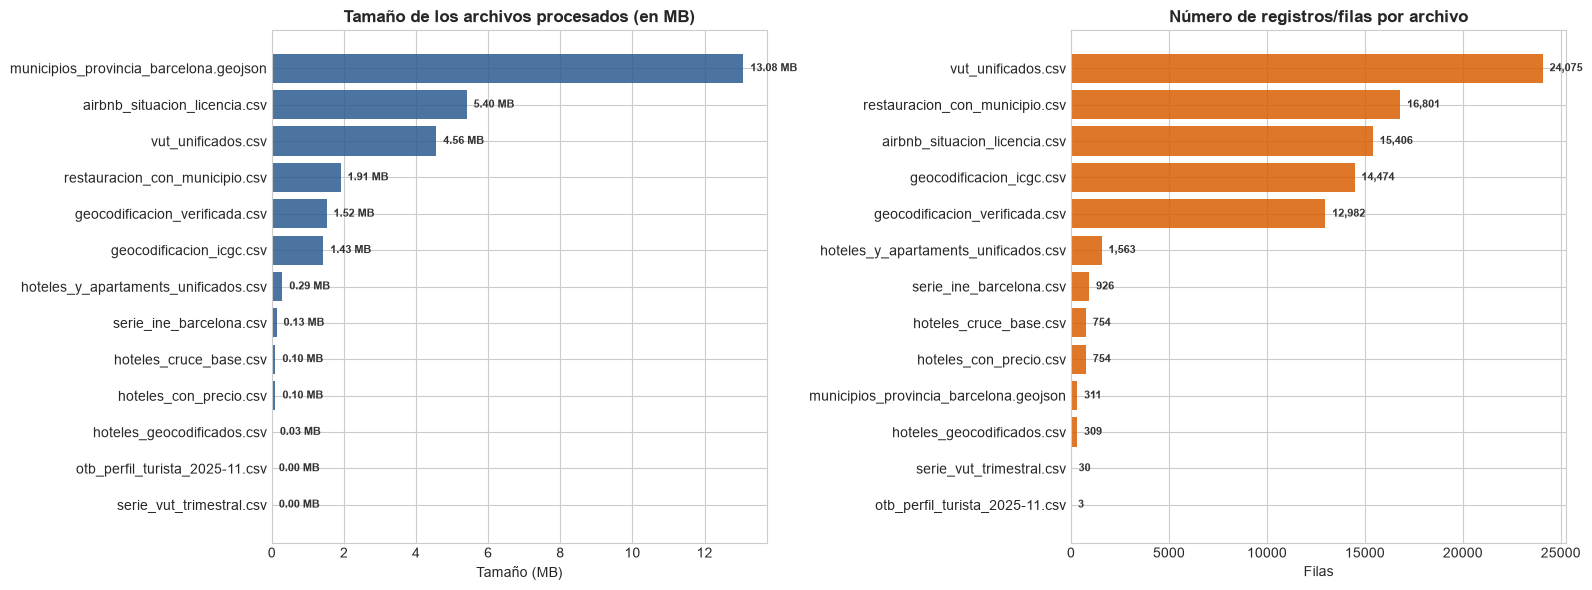

In [3]:
processed_dir = r"../../data/processed"
if not os.path.exists(processed_dir):
    processed_dir = r"../data/processed"

df_resumen_global = escanear_directorio_procesado(processed_dir)

print("--- CATÁLOGO EJECUTIVO DE DATOS PROCESADOS (DATA/PROCESSED) ---")
display(df_resumen_global)

# Gráfico comparativo de volumen y tamaño
generar_grafico_resumen_archivos(df_resumen_global)

## 2. Ficha detallada y auditoría archivo por archivo

A continuación se muestra el detalle técnico, la estructura de columnas, los tipos de datos, los niveles de nulos y la vista previa para cada uno de los 13 conjuntos de datos procesados.

In [4]:
archivos_procesados = sorted(os.listdir(processed_dir))

for f in archivos_procesados:
    ruta = os.path.join(processed_dir, f)
    mostrar_auditoria_archivo(ruta, max_filas_muestra=3)

FICHA TÉCNICA: airbnb_situacion_licencia.csv
Dimensiones: 15,406 filas x 29 columnas
Memoria ocupada: 12.89 MB
--- COLUMNAS Y COBERTURA DE DATOS ---


,tipo_dato,valores_nulos,pct_nulos
id,int64,0,0.00
name,str,0,0.00
host_id,float64,113,0.73
host_name,str,200,1.30
calculated_host_listings_count,float64,113,0.73
neighbourhood_group,str,0,0.00
neighbourhood,str,0,0.00
latitude,float64,0,0.00
longitude,float64,0,0.00
room_type,str,0,0.00


--- VISTA PREVIA (PRIMERAS FILAS) ---


,id,name,host_id,host_name,calculated_host_listings_count,neighbourhood_group,neighbourhood,latitude,longitude,room_type,...,regimen_declarado,exencion,licencia_existe,fuera_de_rango,situacion,sujeto_a_vut,actividad_reciente,host_acredita_en_otro,sin_licencia,sin_licencia_host_acredita
0,18674,Huge flat for 8 people close to Sagrada Familia,71615.0,Maria Y Mireia Barcelona4Seasons,20.0,Eixample,la Sagrada Família,41.405560,2.17262,Entire home/apt,...,NaN,NaN,True,False,licencia_verificada,True,True,False,False,False
1,23197,CCIB Forum· Large Balcony · 5 min walk to CCIB,90417.0,Marnie,1.0,Sant Martí,el Besòs i el Maresme,41.412432,2.21975,Entire home/apt,...,NaN,NaN,True,False,licencia_verificada,True,True,False,False,False
2,34981,VIDRE HOME PLAZA REAL on LAS RAMBLAS,73163.0,Andres,2.0,Ciutat Vella,el Barri Gòtic,41.379780,2.17623,Entire home/apt,...,NaN,NaN,False,True,licencia_no_encontrada,True,True,False,True,False


FICHA TÉCNICA: geocodificacion_icgc.csv
Dimensiones: 14,474 filas x 9 columnas
Memoria ocupada: 4.06 MB
--- COLUMNAS Y COBERTURA DE DATOS ---


...

,trimestre,anyo,stock,altas,bajas,variacion_neta
0,2018_2T,2018,9603,NaN,NaN,NaN
1,2018_3T,2018,9613,25.0,15.0,10.0
2,2018_4T,2018,9581,2.0,34.0,-32.0


FICHA TÉCNICA: vut_unificados.csv
Dimensiones: 24,075 filas x 24 columnas
Memoria ocupada: 23.32 MB
--- COLUMNAS Y COBERTURA DE DATOS ---


,tipo_dato,valores_nulos,pct_nulos
licencia_id,str,0,0.00
nombre_comercial,str,100,0.42
municipio,str,0,0.00
codi_ine,float64,100,0.42
comarca,str,100,0.42
tipo_via,str,0,0.00
nombre_via,str,0,0.00
numero,str,0,0.00
piso,str,5253,21.82
puerta,str,6965,28.93


--- VISTA PREVIA (PRIMERAS FILAS) ---


,licencia_id,nombre_comercial,municipio,codi_ine,comarca,tipo_via,nombre_via,numero,piso,puerta,...,tipo,es_persona_fisica,lat,lon,plazas,distrito,barrio,metodo_match,coordenada_compartida,nivel_geo
0,HUTB-000001,Sense especificar,Barcelona,80193.0,Barcelonès,Carrer,Marina,306,1,4,...,vut,False,41.405684,2.173062,6.0,L'EIXAMPLE,la Sagrada Família,codigo_registro,True,coordenada
1,HUTB-000002,Sense especificar,Barcelona,80193.0,Barcelonès,Carrer,Marina,306,2,1,...,vut,False,41.405684,2.173062,6.0,L'EIXAMPLE,la Sagrada Família,codigo_registro,True,coordenada
2,HUTB-000003,Sense especificar,Barcelona,80193.0,Barcelonès,Carrer,Marina,306,2,2,...,vut,False,41.405684,2.173062,5.0,L'EIXAMPLE,la Sagrada Família,codigo_registro,True,coordenada


## 3. Visualización de capa geoespacial provincial

Visualización cartográfica de la capa `municipios_provincia_barcelona.geojson` que sirve de base territorial para los análisis urbanos y turísticos.

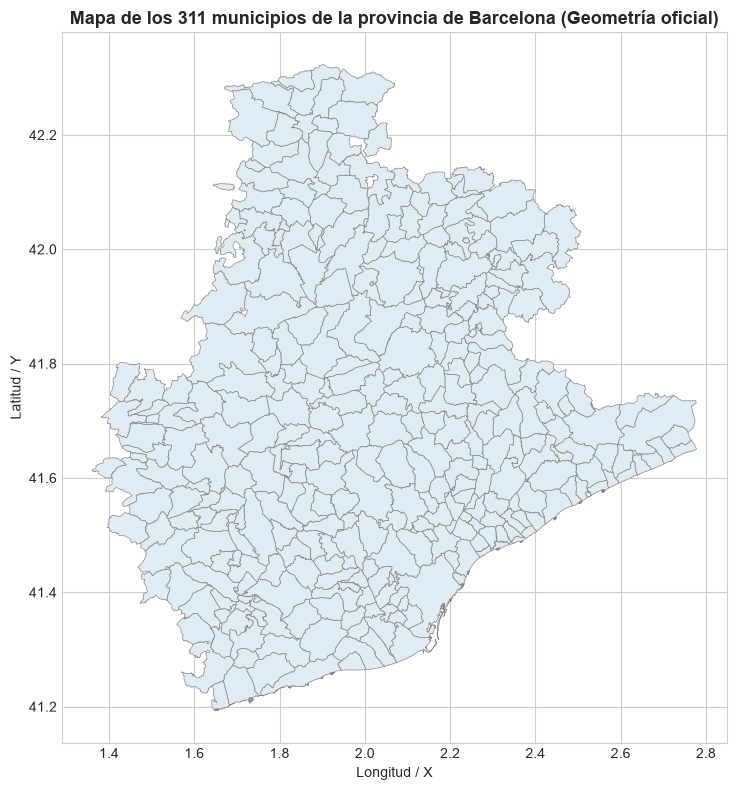

In [5]:
ruta_geojson = os.path.join(processed_dir, "municipios_provincia_barcelona.geojson")
if os.path.exists(ruta_geojson):
    visualizar_mapa_municipios(ruta_geojson)

## 4. Resumen de hallazgos y estado de `data/processed/`

### Resumen del catálogo de datos procesados
- **Total de conjuntos de datos**: 13 archivos (12 archivos CSV/GeoJSON y 1 archivo auxiliar de OTB).
- **Dataset de mayor volumen de registros**: `vut_unificados.csv` con **24.075 viviendas turísticas** unificadas.
- **Dataset de mayor peso**: `municipios_provincia_barcelona.geojson` con **13,08 MB** conteniendo la geometría detallada de los 311 municipios de la provincia.
- **Capa de restauración**: `restauracion_con_municipio.csv` con **16.801 establecimientos** enriquecidos con su término municipal.
- **Capa de oferta de Airbnb**: `airbnb_situacion_licencia.csv` con **15.406 anuncios** procesados con estado de licencia.
- **Capa de alojamiento hotelero**: `hoteles_y_apartaments_unificados.csv` (**1.563 locales**) y `hoteles_con_precio.csv` (**754 hoteles**).
- **Geocodificación**: `geocodificacion_icgc.csv` (14.474 registros) y `geocodificacion_verificada.csv` (12.982 registros) para soporte de mapas.
- **Series temporales e indicadores**: `serie_ine_barcelona.csv` (926 registros), `serie_vut_trimestral.csv` (30 trimestres) y `otb_perfil_turista_2025-11.csv`.